# School Bus Routing Problem (SBRP) Analysis

This notebook implements and visualizes two different algorithms for solving the School Bus Routing Problem:
1.  **Greedy Algorithm:** A heuristic that builds routes by iteratively choosing the nearest unvisited stop.
2.  **Divide and Conquer Algorithm:** A two-phase method that first clusters stops geographically and then solves the Traveling Salesman Problem (TSP) for each cluster.

We will use a predefined graph structure (adjacency list) and supplementary data (coordinates and student counts) to run the simulation. **Stop "0" is treated as the school/depot.**

## 1. Setup and Imports

First, we import the necessary libraries. `heapq` is added for the priority queue in Dijkstra's algorithm.

In [7]:
import math
import random
import re
import heapq
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import networkx as nx
from sklearn.manifold import MDS
from sklearn.preprocessing import MinMaxScaler

## 2. Data Representation and Helper Functions

Here, we define the `Stop` class, a function to calculate route cost, and a new `find_shortest_path` function that uses Dijkstra's algorithm to find the shortest path between two nodes in the graph, allowing for traversal through intermediate stops.

In [8]:
class Stop:
    """Represents a single bus stop with its properties."""
    def __init__(self, id, x, y, student_count):
        self.id = id
        self.x = x
        self.y = y
        self.coords = (x, y)
        self.student_count = student_count

    def __repr__(self):
        return f"Stop({self.id})"

def calculate_route_cost(route, cost_matrix):
    """Calculates the total distance of a single route by summing its segments."""
    total_distance = 0
    for i in range(len(route) - 1):
        loc1_id = route[i].id
        loc2_id = route[i+1].id
        total_distance += cost_matrix.get(loc1_id, {}).get(loc2_id, 0)
    return total_distance

def find_shortest_path(graph, start_id):
    """Finds the shortest path from a start node to all other nodes using Dijkstra's algorithm."""
    distances = {node: float('inf') for node in graph}
    distances[start_id] = 0
    previous_nodes = {node: None for node in graph}
    
    pq = [(0, start_id)]

    while pq:
        current_distance, current_node_id = heapq.heappop(pq)

        if current_distance > distances[current_node_id]:
            continue

        for neighbor_id, weight in graph.get(current_node_id, {}).items():
            distance = current_distance + weight
            if distance < distances[neighbor_id]:
                distances[neighbor_id] = distance
                previous_nodes[neighbor_id] = current_node_id
                heapq.heappush(pq, (distance, neighbor_id))
    
    return distances, previous_nodes

def reconstruct_path(previous_nodes, end_id):
    """Reconstructs the shortest path from the end node back to the start."""
    path = []
    current_id = end_id
    while current_id is not None:
        path.append(current_id)
        current_id = previous_nodes[current_id]
    return path[::-1] # Reverse the path to get start -> end

## 3. Algorithm Implementations

The algorithms now use the `find_shortest_path` function to navigate the graph, making them more robust for sparsely connected networks.

In [9]:
# --- Algorithm 1: Greedy Algorithm ---
def greedy_route_planner(stops, school, cost_matrix, bus_capacity, stop_map):
    """
    Constructs bus routes using a greedy 'nearest unvisited stop' strategy,
    using Dijkstra's algorithm to find the true shortest path.
    """
    unvisited_stops = list(stops)
    all_routes = []
    route_number = 1

    while unvisited_stops:
        print(f"--- Starting new route (Bus {route_number}) ---")
        print(f"Unvisited stops remaining: {len(unvisited_stops)}")
        current_route = [school]
        current_load = 0
        current_location_id = school.id
        stops_added_to_this_route = 0

        while True:
            distances, previous_nodes = find_shortest_path(cost_matrix, current_location_id)
            next_stop = None
            min_distance = float('inf')

            for stop in unvisited_stops:
                if current_load + stop.student_count <= bus_capacity:
                    distance = distances.get(stop.id, float('inf'))
                    if distance < min_distance:
                        min_distance = distance
                        next_stop = stop

            if next_stop:
                stops_added_to_this_route += 1
                path_ids = reconstruct_path(previous_nodes, next_stop.id)
                for stop_id in path_ids[1:]:
                    current_route.append(stop_map[stop_id])
                
                print(f"  Adding Stop {next_stop.id} to route via path {path_ids}. Path cost: {min_distance:.2f}. New load: {current_load + next_stop.student_count}/{bus_capacity}")
                current_load += next_stop.student_count
                current_location_id = next_stop.id
                unvisited_stops.remove(next_stop)
            else:
                print("  No more valid stops can be added to this bus (either full or no reachable stops).")
                break
        
        # *** FIX FOR INFINITE LOOP ON DISCONNECTED GRAPHS ***
        if stops_added_to_this_route == 0:
            print(f"\n[ERROR] Could not find a path to any of the remaining {len(unvisited_stops)} stops.")
            print(f"Unreachable stops: {[s.id for s in unvisited_stops]}")
            print("Stopping greedy algorithm to prevent infinite loop.")
            break

        distances, previous_nodes = find_shortest_path(cost_matrix, current_location_id)
        path_to_school = reconstruct_path(previous_nodes, school.id)
        for stop_id in path_to_school[1:]:
            current_route.append(stop_map[stop_id])
        
        all_routes.append(current_route)
        print(f"--- Finished route (Bus {route_number}). Final path: {[s.id for s in current_route]} ---")
        route_number += 1
    
    if not unvisited_stops:
        print("\nAll stops have been visited.")
    return all_routes

# --- Algorithm 2: Divide and Conquer (Clustering-Based) ---
def solve_tsp_for_cluster(cluster_stops, school, cost_matrix, stop_map):
    """Solves the TSP for a single cluster using a nearest-neighbor heuristic with Dijkstra's."""
    if not cluster_stops:
        return [school, school]

    tour = [school]
    current_location_id = school.id
    unvisited_in_cluster = list(cluster_stops)

    while unvisited_in_cluster:
        distances, previous_nodes = find_shortest_path(cost_matrix, current_location_id)
        next_stop = None
        min_distance = float('inf')

        for stop in unvisited_in_cluster:
            distance = distances.get(stop.id, float('inf'))
            if distance < min_distance:
                min_distance = distance
                next_stop = stop
        
        if next_stop is None:
            print(f"[Warning] Could not find path to any remaining stops in cluster from {current_location_id}")
            break

        path_ids = reconstruct_path(previous_nodes, next_stop.id)
        for stop_id in path_ids[1:]:
            tour.append(stop_map[stop_id])
        
        current_location_id = next_stop.id
        unvisited_in_cluster.remove(next_stop)
    
    distances, previous_nodes = find_shortest_path(cost_matrix, current_location_id)
    path_to_school = reconstruct_path(previous_nodes, school.id)
    for stop_id in path_to_school[1:]:
        tour.append(stop_map[stop_id])
        
    return tour

def clustering_based_planner(stops, school, num_buses, cost_matrix, stop_map):
    """Generates routes by first clustering stops and then solving TSP for each cluster."""
    stop_coords = np.array([s.coords for s in stops])
    if not stops:
        return [], None
    
    if len(stop_coords) < num_buses:
        print(f"Warning: More buses ({num_buses}) than stops ({len(stop_coords)}). Reducing number of buses.")
        num_buses = len(stop_coords)
        
    kmeans = KMeans(n_clusters=num_buses, random_state=42, n_init=10).fit(stop_coords)
    clusters = [[] for _ in range(num_buses)]
    for i, stop in enumerate(stops):
        clusters[kmeans.labels_[i]].append(stop)

    all_routes = []
    for i, cluster in enumerate(clusters):
        print(f"-- Solving TSP for Cluster {i} --")
        route = solve_tsp_for_cluster(cluster, school, cost_matrix, stop_map)
        all_routes.append(route)
        
    return all_routes, kmeans.labels_

## 4. Visualization Function

This function plots the results, showing the school, stop locations, and the generated bus routes. It can color-code stops by cluster for the Divide and Conquer algorithm.

In [10]:
def visualize_routes(stops, school, routes, algorithm_name, cluster_labels=None):
    """
    Plots the school, bus stops, and the generated routes.
    """
    plt.figure(figsize=(14, 12))
    
    # Plot school
    plt.scatter(school.coords[0], school.coords[1], c='red', marker='s', s=200, label=f'School (Stop {school.id})', zorder=5)
    
    # Plot stops (excluding the school)
    pickup_stops = [s for s in stops if s.id != school.id]
    if pickup_stops:
        if cluster_labels is not None:
            # Adjust cluster labels to match the pickup_stops list
            stop_id_to_label = {stop.id: label for stop, label in zip(stops, cluster_labels)}
            ordered_labels = [stop_id_to_label[s.id] for s in pickup_stops]
            unique_labels = sorted(list(set(ordered_labels)))
            scatter = plt.scatter([s.x for s in pickup_stops], [s.y for s in pickup_stops], c=ordered_labels, cmap='viridis', s=60, zorder=4)
            plt.legend(handles=scatter.legend_elements()[0], labels=[f'Cluster {i}' for i in unique_labels], title="Clusters")
        else:
            plt.scatter([s.x for s in pickup_stops], [s.y for s in pickup_stops], c='blue', s=60, label='Stops', zorder=4)

    # Plot routes
    colors = plt.cm.rainbow(np.linspace(0, 1, len(routes)))
    for i, route in enumerate(routes):
        if len(route) > 1:
            route_coords = [loc.coords for loc in route]
            x_coords, y_coords = zip(*route_coords)
            plt.plot(x_coords, y_coords, color=colors[i], marker='o', markersize=5, linestyle='-')

    plt.title(f'School Bus Routes from {algorithm_name}', fontsize=16)
    plt.xlabel('X Coordinate')
    plt.ylabel('Y Coordinate')
    plt.grid(True)
    # Re-add school to legend to ensure it appears
    handles, labels = plt.gca().get_legend_handles_labels()
    school_handle = plt.Line2D([0], [0], marker='s', color='w', label=f'School (Stop {school.id})', markersize=10, markerfacecolor='red')
    handles.append(school_handle)
    plt.legend(handles=handles)
    plt.show()

## 5. Data Loading and Simulation

Here we define the simulation parameters and load the data. A `stop_map` is created for quick lookups, and the capacity check is performed before running the updated algorithms.

f:\GitRepos\sbrp-adv-alg\.venv\lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


Total students to pick up: 876
Initial total bus capacity: 135 (3 buses * 45 capacity)

New total bus capacity: 900

--- Running Greedy Algorithm ---
--- Starting new route (Bus 1) ---
Unvisited stops remaining: 88
  Adding Stop 7 to route via path ['1', '7']. Path cost: 2.00. New load: 11/45
  Adding Stop 8 to route via path ['7', '8']. Path cost: 1.00. New load: 24/45
  Adding Stop 26 to route via path ['8', '7', '26']. Path cost: 4.00. New load: 37/45
  Adding Stop 6 to route via path ['26', '6']. Path cost: 2.00. New load: 43/45
  No more valid stops can be added to this bus (either full or no reachable stops).
--- Finished route (Bus 1). Final path: ['1', '7', '8', '7', '26', '6', '26', '1'] ---
--- Starting new route (Bus 2) ---
Unvisited stops remaining: 84
  Adding Stop 27 to route via path ['1', '26', '27']. Path cost: 3.00. New load: 9/45
  Adding Stop 28 to route via path ['27', '28']. Path cost: 1.00. New load: 24/45
  Adding Stop 62 to route via path ['28', '62']. Path cos

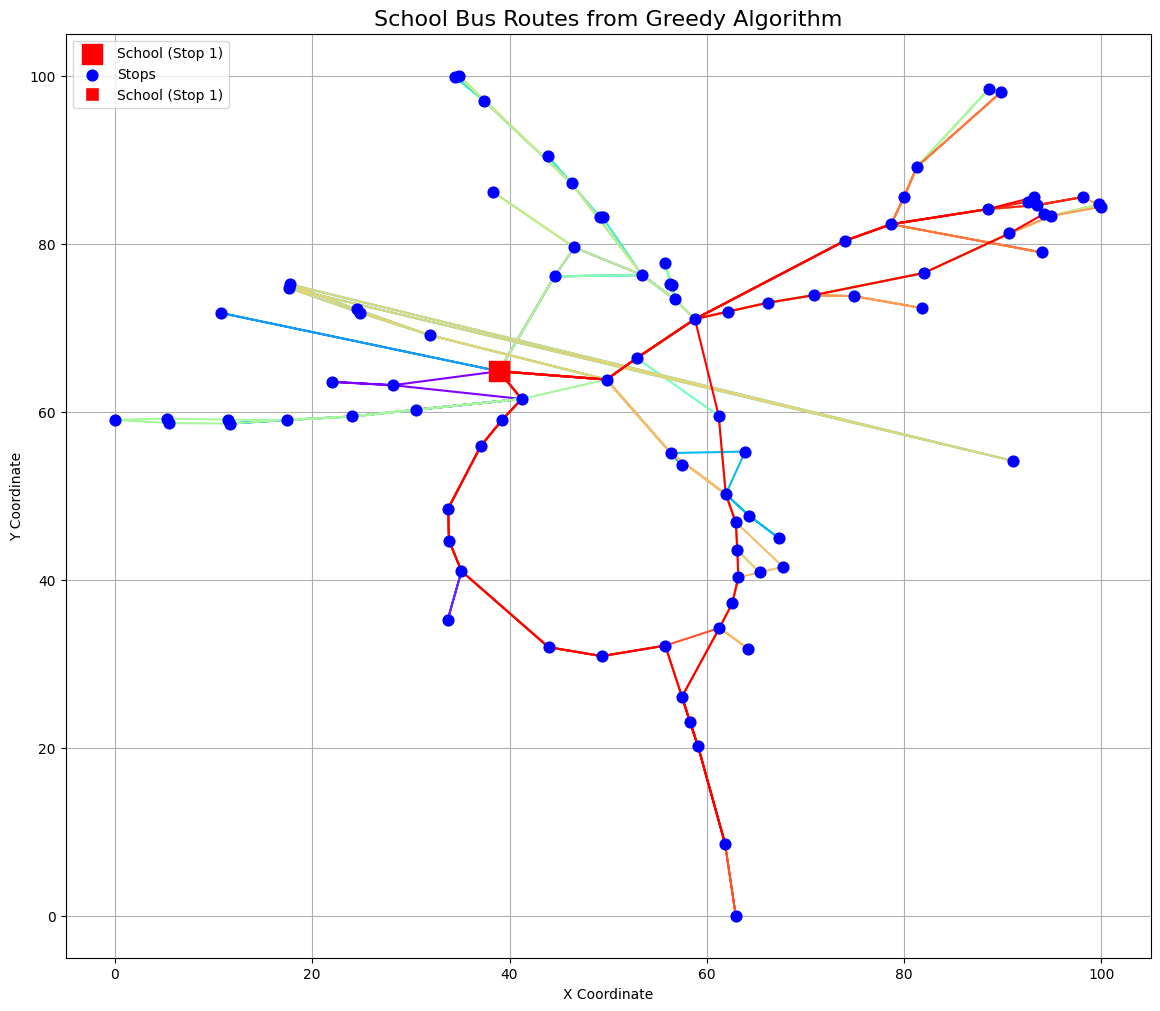

C:\Users\aaron\AppData\Local\Temp\ipykernel_2384\1944838522.py:19: UserWarning: Mismatched number of handles and labels: len(handles) = 8 len(labels) = 20
  plt.legend(handles=scatter.legend_elements()[0], labels=[f'Cluster {i}' for i in unique_labels], title="Clusters")


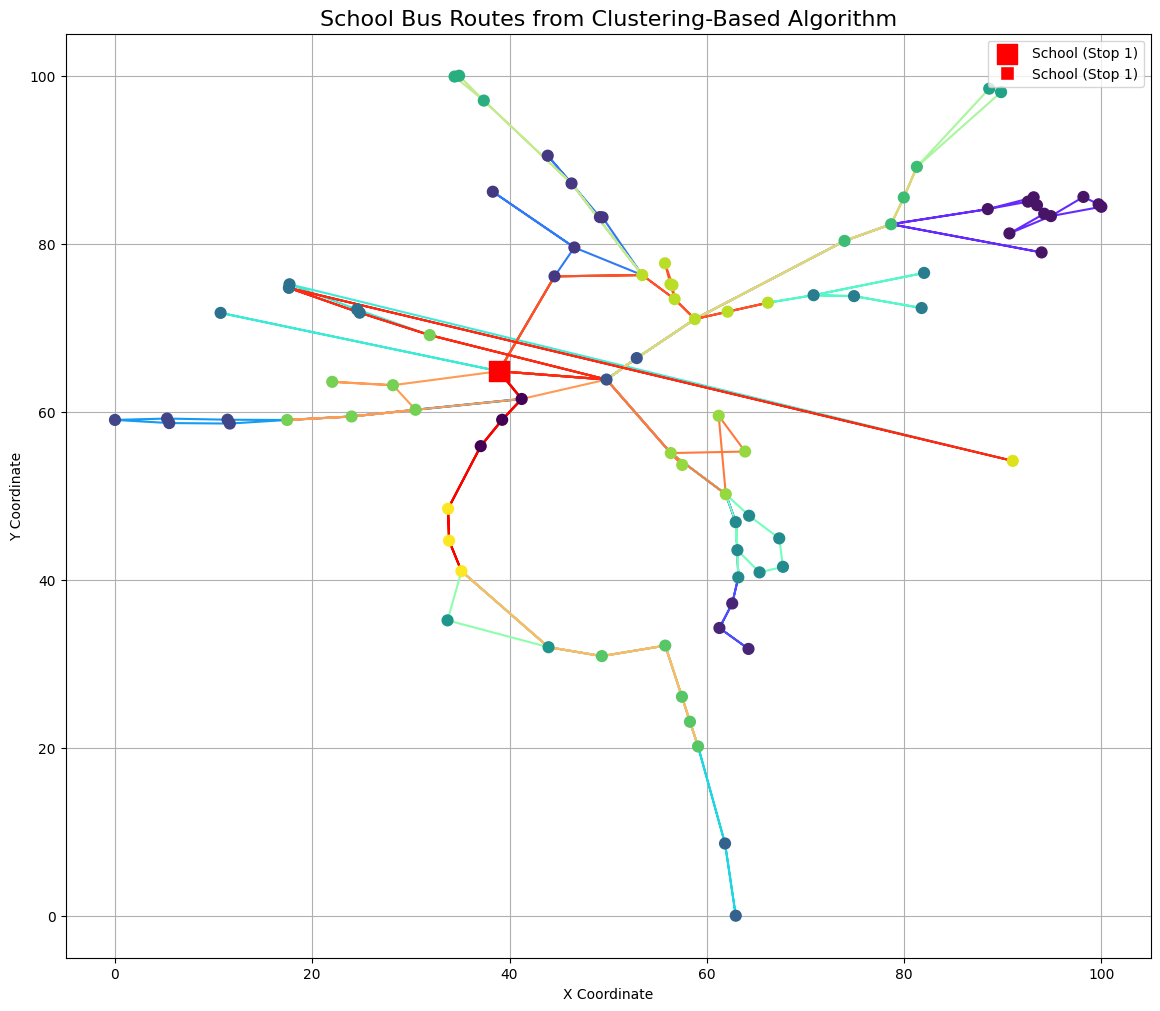

In [ ]:
# Simulation Settings
NUM_BUSES = 3
BUS_CAPACITY = 45
AREA_WIDTH = 100
AREA_HEIGHT = 100

# 1. Load Provided Graph Data (Large version, cleaned and connected)
adj_list = {
    "1": [["2", 4], ["6", 1], ["7", 2], ["26", 2], ["34", 3]],
    "2": [["1", 4]],
    "3": [["4", 1], ["12", 1]],
    "4": [["3", 1], ["9", 1]],
    "5": [["6", 1], ["9", 1]],
    "6": [["1", 6], ["5", 1], ["7", 3], ["26", 2]],
    "7": [["1", 2], ["6", 3], ["8", 1], ["26", 3]],
    "8": [["7", 1]],
    "9": [["4", 1], ["5", 1], ["10", 1]],
    "10": [["9", 1], ["11", 1]],
    "11": [["10", 1], ["12", 1]],
    "12": [["3", 1], ["11", 1]],
    "13": [["14", 2]],
    "14": [["13", 2], ["19", 2], ["91", 2]],
    "15": [["16", 1], ["17", 1], ["18", 1]],
    "16": [["15", 1], ["17", 1]],
    "17": [["15", 1], ["16", 1], ["18", 1]],
    "18": [["15", 1], ["17", 1], ["19", 1]],
    "19": [["14", 2], ["18", 1], ["20", 2], ["21", 2], ["87", 3], ["91", 3]],
    "20": [["19", 2], ["21", 1], ["87", 2]],
    "21": [["19", 2], ["20", 1], ["87", 2]],
    "22": [["23", 1], ["63", 2], ["81", 1], ["88", 2]],
    "23": [["22", 1], ["24", 4]],
    "24": [["18", 1], ["23", 4], ["25", 2], ["33", 2], ["78", 1]],
    "25": [["24", 2], ["33", 1], ["34", 1]],
    "26": [["1", 2], ["6", 2], ["7", 3], ["27", 1], ["34", 2]],
    "27": [["26", 1], ["28", 1]],
    "28": [["27", 1], ["62", 2]],
    "29": [["58", 1], ["59", 3], ["60", 3]],
    "30": [["31", 1], ["32", 2], ["33", 2], ["46", 1], ["34", 3]],
    "31": [["30", 1]],
    "32": [["30", 2], ["33", 2], ["46", 2]],
    "33": [["24", 4], ["25", 3], ["30", 2], ["32", 2], ["46", 3]],
    # *** THIS IS THE FIX: Added a 'bridge' from Stop 34 to 35 ***
    "34": [["1", 3], ["25", 1], ["26", 2], ["30", 3], ["35", 4]],
    "35": [["36", 1], ["40", 1], ["34", 4]], # Also add the connection back for symmetry
    "36": [["35", 1], ["37", 1]],
    "37": [["36", 1], ["38", 1]],
    "38": [["37", 1], ["39", 1]],
    "39": [["38", 1], ["40", 1]],
    "40": [["35", 1], ["39", 1]],
    "41": [["42", 1], ["56", 3], ["57", 2]],
    "42": [["41", 1], ["43", 1]],
    "43": [["42", 1], ["44", 4]],
    "44": [["43", 4], ["45", 3]],
    "45": [["44", 3]],
    "46": [["30", 2], ["32", 3], ["33", 3], ["47", 1], ["52", 1]],
    "47": [["46", 1], ["48", 1], ["50", 2], ["52", 2]],
    "48": [["47", 1], ["49", 1], ["50", 2], ["53", 1]],
    "49": [["48", 1], ["50", 1], ["53", 1]],
    "50": [["47", 2], ["48", 2], ["49", 1], ["51", 1]],
    "51": [["50", 1], ["52", 1]],
    "52": [["46", 1], ["47", 1], ["51", 1]],
    "53": [["48", 1], ["49", 1], ["54", 1]],
    "54": [["53", 1], ["56", 1]],
    "55": [["56", 1]],
    "57": [["41", 2], ["56", 1], ["58", 1]],
    "58": [["57", 1]],
    "59": [["60", 2]],
    "60": [["59", 2], ["61", 1]],
    "61": [["60", 1], ["62", 1]],
    "62": [["28", 2], ["61", 1]],
    "63": [["22", 2], ["64", 1], ["66", 1], ["67", 1]],
    "64": [["63", 1], ["65", 1], ["66", 1]],
    "65": [["64", 1], ["66", 1], ["71", 1], ["72", 1]],
    "66": [["63", 1], ["64", 1], ["65", 1], ["67", 1], ["68", 1], ["71", 1]],
    "67": [["63", 1], ["66", 1], ["68", 1]],
    "68": [["66", 1], ["67", 1], ["69", 1], ["70", 1], ["71", 1]],
    "69": [["68", 1], ["70", 1], ["71", 1]],
    "70": [["68", 1], ["69", 1], ["71", 1]],
    "71": [["65", 1], ["66", 1], ["68", 1], ["69", 1], ["70", 1], ["72", 1]],
    "72": [["65", 1], ["71", 1], ["73", 2]],
    "73": [["72", 2], ["76", 2]],
    "74": [["75", 1]],
    "75": [["74", 1], ["76", 1]],
    "76": [["73", 2], ["77", 1]],
    "77": [["76", 1], ["78", 1]],
    "78": [["24", 1], ["77", 1]],
    "79": [["80", 2], ["82", 3]],
    "80": [["79", 2], ["82", 3]],
    "81": [["22", 1], ["82", 1]],
    "82": [["79", 3], ["80", 3], ["81", 1]],
    "83": [["84", 1], ["85", 1], ["87", 4]],
    "84": [["83", 1], ["85", 1]],
    "85": [["83", 1], ["84", 1], ["87", 3]],
    "86": [["87", 1]],
    "87": [["85", 3], ["86", 1]],
    "91": [["14", 2], ["19", 2], ["1", 3]]
}

# 2. Create Stop Objects and Full Cost Matrix via MDS

# --- STEP A: Build a NetworkX graph to calculate real distances ---
G = nx.Graph()
all_stop_ids = set(adj_list.keys())

# Build the graph from the adjacency list
for stop_id, neighbors in adj_list.items():
    all_stop_ids.add(str(stop_id))
    for neighbor in neighbors:
        # Assuming neighbor structure is (neighbor_id, weight)
        # If your adj_list just has IDs, remove [1] and set weight=1
        nbr_id = str(neighbor[0])
        weight = neighbor[1] if len(neighbor) > 1 else 1 
        G.add_edge(str(stop_id), nbr_id, weight=weight)
        all_stop_ids.add(nbr_id)

# Ensure we have a sorted list of IDs so indices match the matrix
sorted_stop_ids = sorted(list(all_stop_ids))
id_to_index = {stop_id: i for i, stop_id in enumerate(sorted_stop_ids)}
n_samples = len(sorted_stop_ids)

# --- STEP B: Generate the All-Pairs Shortest Path Matrix ---
# Initialize matrix with infinity
cost_matrix = np.full((n_samples, n_samples), np.inf)
np.fill_diagonal(cost_matrix, 0)

# Compute shortest paths (Dijkstra/Floyd-Warshall)
# dict(nx.all_pairs_dijkstra_path_length(G)) is efficient for sparse graphs
path_lengths = dict(nx.all_pairs_dijkstra_path_length(G))

for i, id_i in enumerate(sorted_stop_ids):
    for j, id_j in enumerate(sorted_stop_ids):
        if id_j in path_lengths.get(id_i, {}):
            cost_matrix[i][j] = path_lengths[id_i][id_j]
        else:
             # Handle disconnected components if necessary
             # Set to a large number so MDS pushes them apart
            cost_matrix[i][j] = np.max(cost_matrix[cost_matrix != np.inf]) * 2

# --- STEP C: Apply MDS to project to 2D ---
# dissimilarity='precomputed' tells MDS we are giving it a distance matrix, not raw data points
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42, normalized_stress='auto')
pos_2d = mds.fit_transform(cost_matrix)

# --- STEP D: Scale coordinates to fit your Area Size ---
# MDS output is centered at 0. We scale it to [0, AREA_WIDTH]
scaler = MinMaxScaler(feature_range=(0, 1))
pos_2d_scaled = scaler.fit_transform(pos_2d)

stop_coordinates = {}
for i, stop_id in enumerate(sorted_stop_ids):
    x = pos_2d_scaled[i][0] * AREA_WIDTH
    y = pos_2d_scaled[i][1] * AREA_HEIGHT
    stop_coordinates[stop_id] = (x, y)

# --- STEP E: Create Objects ---
school_id = '1'
# Ensure school is in the map; if not, default to center or existing coord
school_coords = stop_coordinates.get(school_id, (AREA_WIDTH/2, AREA_HEIGHT/2))
school = Stop(school_id, school_coords[0], school_coords[1], 0)

stops = []
for stop_id in all_stop_ids:
    if stop_id != school_id:
        coords = stop_coordinates[stop_id]
        stops.append(Stop(stop_id, coords[0], coords[1], random.randint(5, 15)))

stop_map = {s.id: s for s in stops}
stop_map[school.id] = school

# --- CHECK AND GUARANTEE BUS CAPACITY ---
total_students = sum(s.student_count for s in stops)
total_capacity = NUM_BUSES * BUS_CAPACITY
print(f"Total students to pick up: {total_students}")
print(f"Initial total bus capacity: {total_capacity} ({NUM_BUSES} buses * {BUS_CAPACITY} capacity)")
if total_students > total_capacity:
    required_buses = math.ceil(total_students / BUS_CAPACITY)
    print(f"\nWarning: Not enough capacity. Required buses: {required_buses}. Adjusting NUM_BUSES from {NUM_BUSES} to {required_buses}.")
    NUM_BUSES = required_buses
    print(f"New total bus capacity: {NUM_BUSES * BUS_CAPACITY}\n")
else:
    print("Sufficient bus capacity available.\n")

# Build the cost matrix directly from the adjacency list
cost_matrix = {stop_id: {} for stop_id in all_stop_ids}
for stop_id, neighbors in adj_list.items():
    for neighbor in neighbors:
        if len(neighbor) == 2:
            neighbor_id, distance = str(neighbor[0]), neighbor[1]
            cost_matrix[stop_id][neighbor_id] = distance
            if neighbor_id not in cost_matrix: cost_matrix[neighbor_id] = {}
            cost_matrix[neighbor_id][stop_id] = distance

# 3. Run Greedy Algorithm
print("--- Running Greedy Algorithm ---")
greedy_routes = greedy_route_planner(stops, school, cost_matrix, BUS_CAPACITY, stop_map)
total_greedy_cost = sum(calculate_route_cost(r, cost_matrix) for r in greedy_routes)
print(f"Generated {len(greedy_routes)} routes.")
print(f"Total distance: {total_greedy_cost:.2f}\n")

# 4. Run Clustering Algorithm
print("--- Running Clustering-Based Algorithm ---")
clustering_routes, labels = clustering_based_planner(stops, school, NUM_BUSES, cost_matrix, stop_map)
total_clustering_cost = sum(calculate_route_cost(r, cost_matrix) for r in clustering_routes)
print(f"Generated {len(clustering_routes)} routes.")
print(f"Total distance: {total_clustering_cost:.2f}\n")

# 5. Visualize Outputs
visualize_routes(stops, school, greedy_routes, "Greedy Algorithm")
if labels is not None:
    visualize_routes(stops, school, clustering_routes, "Clustering-Based Algorithm", cluster_labels=labels)

--- BENCHMARKING SIZE 5, TRIAL 1/500 ---
-- Solving TSP for Cluster 0 --
-- Solving TSP for Cluster 1 --
--- BENCHMARKING SIZE 5, TRIAL 2/500 ---
-- Solving TSP for Cluster 0 --
-- Solving TSP for Cluster 1 --
--- BENCHMARKING SIZE 5, TRIAL 3/500 ---
-- Solving TSP for Cluster 0 --
-- Solving TSP for Cluster 1 --
--- BENCHMARKING SIZE 5, TRIAL 4/500 ---
-- Solving TSP for Cluster 0 --
-- Solving TSP for Cluster 1 --
--- BENCHMARKING SIZE 5, TRIAL 5/500 ---
-- Solving TSP for Cluster 0 --
--- BENCHMARKING SIZE 5, TRIAL 6/500 ---
-- Solving TSP for Cluster 0 --
-- Solving TSP for Cluster 1 --
--- BENCHMARKING SIZE 5, TRIAL 7/500 ---
-- Solving TSP for Cluster 0 --
--- BENCHMARKING SIZE 5, TRIAL 8/500 ---
-- Solving TSP for Cluster 0 --
-- Solving TSP for Cluster 1 --
--- BENCHMARKING SIZE 5, TRIAL 9/500 ---
-- Solving TSP for Cluster 0 --
-- Solving TSP for Cluster 1 --
--- BENCHMARKING SIZE 5, TRIAL 10/500 ---
-- Solving TSP for Cluster 0 --
-- Solving TSP for Cluster 1 --
--- BENCHMARK

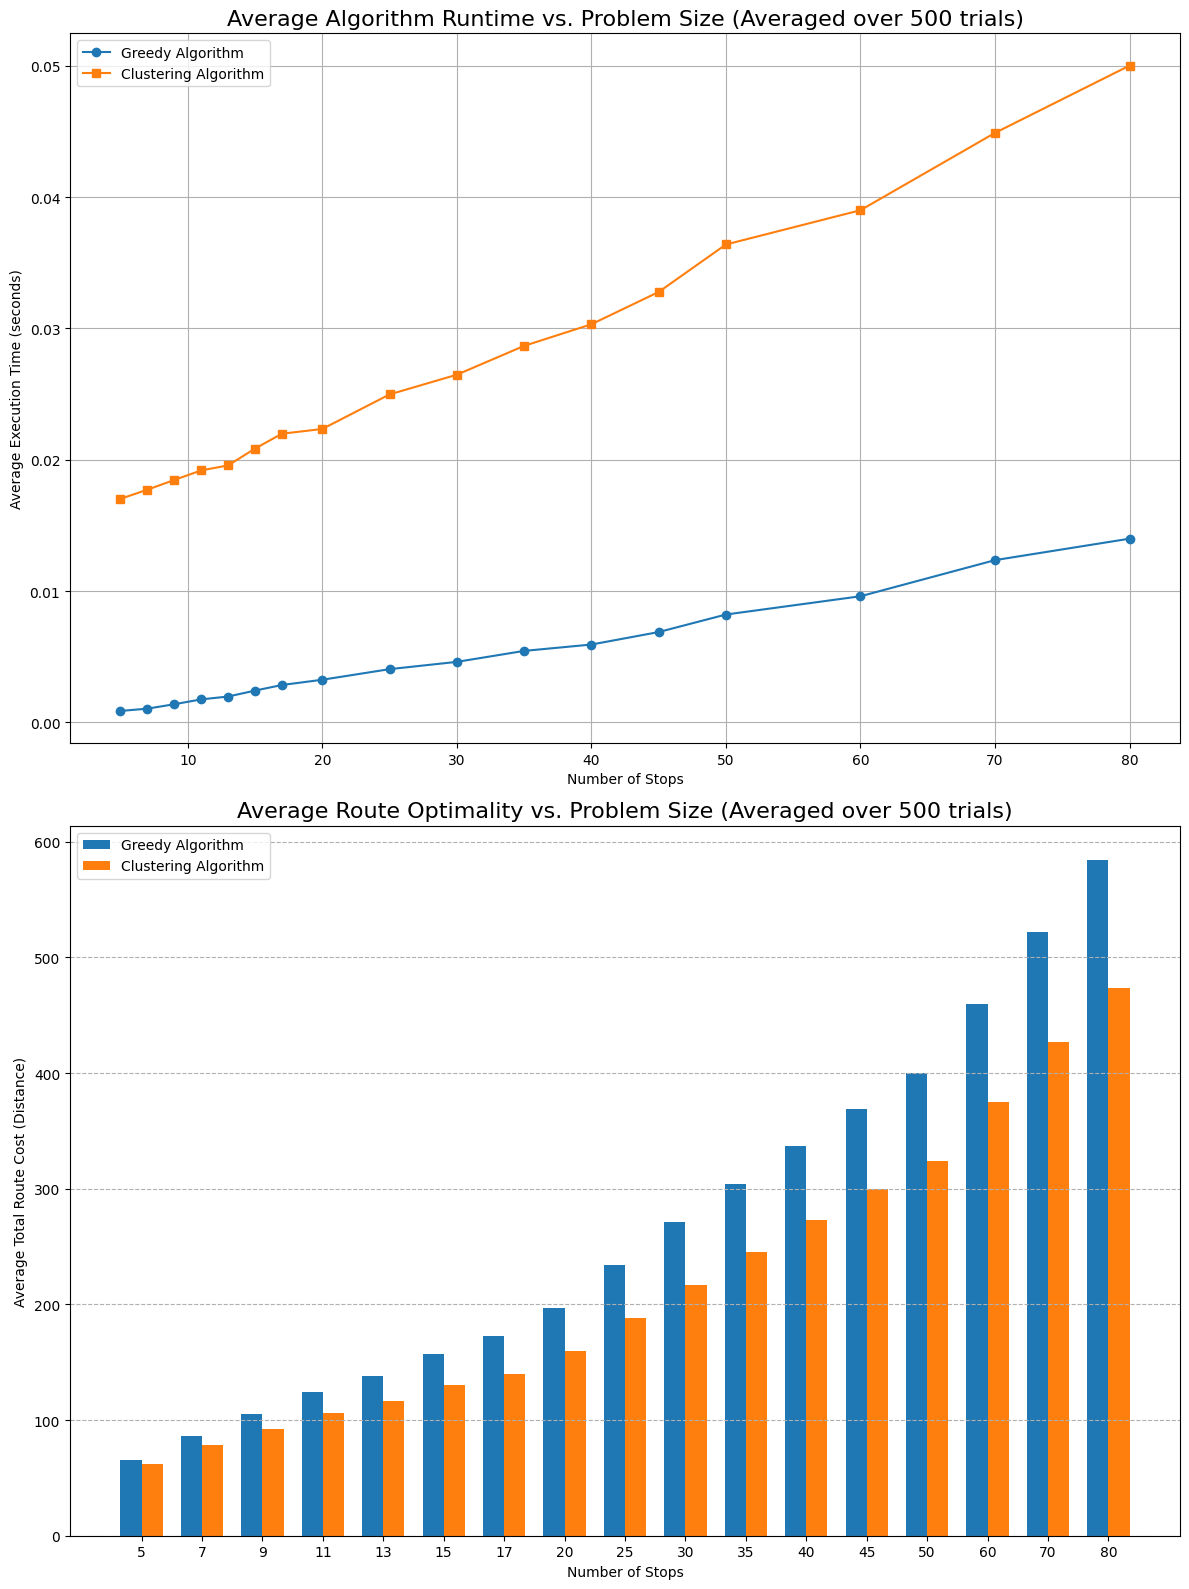


Benchmark Results Summary (Averaged over 500 trials per size):
    Problem Size  Greedy Time (s)  Greedy Cost  Clustering Time (s)  \
0              5         0.000878       65.368             0.017030   
1              7         0.001054       86.634             0.017725   
2              9         0.001391      104.916             0.018467   
3             11         0.001758      123.978             0.019193   
4             13         0.001977      138.316             0.019574   
5             15         0.002428      157.284             0.020855   
6             17         0.002854      172.936             0.021987   
7             20         0.003254      197.082             0.022348   
8             25         0.004061      233.688             0.024980   
9             30         0.004616      270.824             0.026479   
10            35         0.005450      304.126             0.028675   
11            40         0.005935      337.094             0.030321   
12           

In [12]:
import time
import pandas as pd
import numpy as np # Make sure numpy is imported if not already

def run_benchmark(all_stops, school, full_cost_matrix, stop_map, problem_sizes, num_trials=5):
    """
    Runs both algorithms multiple times for each problem size to get an
    averaged, more reliable comparison of performance and solution quality.
    """
    trial_results = []
    
    # Create a quiet version of the greedy planner to avoid excessive logging
    def quiet_greedy_planner(stops, school, cost_matrix, bus_capacity, stop_map):
        # (This is a condensed version of the main function without print statements)
        unvisited_stops = list(stops)
        all_routes = []
        while unvisited_stops:
            current_route, current_load, current_location_id, stops_added = [school], 0, school.id, 0
            while True:
                distances, prev_nodes = find_shortest_path(cost_matrix, current_location_id)
                next_stop, min_dist = None, float('inf')
                for s in unvisited_stops:
                    if current_load + s.student_count <= bus_capacity:
                        dist = distances.get(s.id, float('inf'))
                        if dist < min_dist: min_dist, next_stop = dist, s
                if next_stop:
                    stops_added += 1
                    path_ids = reconstruct_path(prev_nodes, next_stop.id)
                    for sid in path_ids[1:]: current_route.append(stop_map[sid])
                    current_load += next_stop.student_count
                    current_location_id = next_stop.id
                    unvisited_stops.remove(next_stop)
                else: break
            if stops_added == 0 and unvisited_stops: break
            distances, prev_nodes = find_shortest_path(cost_matrix, current_location_id)
            path_to_school = reconstruct_path(prev_nodes, school.id)
            for sid in path_to_school[1:]: current_route.append(stop_map[sid])
            all_routes.append(current_route)
        return all_routes

    for size in problem_sizes:
        for trial in range(1, num_trials + 1):
            print(f"--- BENCHMARKING SIZE {size}, TRIAL {trial}/{num_trials} ---")
            
            if size > len(all_stops): continue
            
            current_stops = random.sample(all_stops, size)
            
            # --- Run Greedy Algorithm ---
            start_time = time.time()
            greedy_routes = quiet_greedy_planner(current_stops, school, full_cost_matrix, BUS_CAPACITY, stop_map)
            greedy_time = time.time() - start_time
            greedy_cost = sum(calculate_route_cost(r, full_cost_matrix) for r in greedy_routes)
            
            # --- Run Clustering Algorithm ---
            total_students_subset = sum(s.student_count for s in current_stops)
            num_buses_for_subset = math.ceil(total_students_subset / BUS_CAPACITY) if total_students_subset > 0 else 1

            start_time = time.time()
            clustering_routes, _ = clustering_based_planner(current_stops, school, num_buses_for_subset, full_cost_matrix, stop_map)
            clustering_time = time.time() - start_time
            clustering_cost = sum(calculate_route_cost(r, full_cost_matrix) for r in clustering_routes)
            
            trial_results.append({
                "Problem Size": size,
                "Greedy Time (s)": greedy_time, "Greedy Cost": greedy_cost,
                "Clustering Time (s)": clustering_time, "Clustering Cost": clustering_cost
            })

    # --- Aggregate the results by taking the average of all trials ---
    df_trials = pd.DataFrame(trial_results)
    df_summary = df_trials.groupby('Problem Size').mean().reset_index()
    return df_summary

# Define the number of trials to run for each problem size
NUM_TRIALS = 500
problem_sizes_to_test = [5, 7, 9, 11, 13, 15, 17, 20, 25, 30, 35, 40, 45, 50, 60, 70, 80]

# Run the benchmark
benchmark_results = run_benchmark(stops, school, cost_matrix, stop_map, problem_sizes_to_test, num_trials=NUM_TRIALS)

# --- Plot the results ---
if not benchmark_results.empty:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 16))

    # Plot 1: Average Runtime Comparison
    ax1.plot(benchmark_results["Problem Size"], benchmark_results["Greedy Time (s)"], marker='o', label="Greedy Algorithm")
    ax1.plot(benchmark_results["Problem Size"], benchmark_results["Clustering Time (s)"], marker='s', label="Clustering Algorithm")
    ax1.set_title(f"Average Algorithm Runtime vs. Problem Size (Averaged over {NUM_TRIALS} trials)", fontsize=16)
    ax1.set_xlabel("Number of Stops")
    ax1.set_ylabel("Average Execution Time (seconds)")
    ax1.legend()
    ax1.grid(True)

    # Plot 2: Average Solution Quality (Optimality) Comparison
    bar_width = 0.35
    index = np.arange(len(benchmark_results["Problem Size"]))
    
    rects1 = ax2.bar(index - bar_width/2, benchmark_results["Greedy Cost"], bar_width, label='Greedy Algorithm')
    rects2 = ax2.bar(index + bar_width/2, benchmark_results["Clustering Cost"], bar_width, label='Clustering Algorithm')

    ax2.set_title(f"Average Route Optimality vs. Problem Size (Averaged over {NUM_TRIALS} trials)", fontsize=16)
    ax2.set_xlabel("Number of Stops")
    ax2.set_ylabel("Average Total Route Cost (Distance)")
    ax2.set_xticks(index)
    ax2.set_xticklabels(benchmark_results["Problem Size"])
    ax2.legend()
    ax2.grid(axis='y', linestyle='--')

    plt.tight_layout()
    plt.show()

# Display the raw data in a table
print(f"\nBenchmark Results Summary (Averaged over {NUM_TRIALS} trials per size):")
print(benchmark_results)